# Notebook to preprocess hourly biospheric CO2 prior fluxes from JSBACH

In [2]:
import numpy as np
import pandas as pd
import xarray as xr
import os
import netCDF4 as nc
import re
from global_land_mask import globe
from scipy.interpolate import griddata
from scipy.ndimage import binary_dilation


import matplotlib.pyplot as plt
import matplotlib as mpl
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.ticker import MultipleLocator

from matplotlib import colors

# JSBACH 202503 version
 * Lat/lon need to be taken from a separate jsbach.nc -file since jsbach for some reason gives a global grid even though this is a regional run - need to manually adjust
 * 0.125 deg resolution - need to interpolate to 0.1 deg resol
 * the last hour of each year in a separate file: join with the main ds

In [3]:
def select_area(aoi, ds):
    # Determine the dimension names for latitude and longitude
    lat_name = 'lat' if 'lat' in ds.dims else 'latitude'
    lon_name = 'lon' if 'lon' in ds.dims else 'longitude'
    
    # Select the area based on the area of interest
    area_subset = ds.sel({lon_name: slice(aoi[0], aoi[1]),
                          lat_name: slice(aoi[2], aoi[3])})
    return area_subset

def extract_year(filename):
    #Extract year from filename
    year = int(re.findall(r'\d{4}', filename)[-1])
    return year


def create_lsm_like(data):
    lon = data["longitude"].values
    lat = data["latitude"].values
    longrid, latgrid = np.meshgrid(lon,lat)
    lsm = globe.is_land(latgrid, longrid)
    return lsm



def to_highres(ds):
    """Helper to extrapolate JSBACH_202503 data from 0.125 deg resolution to 0.1. Only works with JSBACH_202503 dataset
    as I had to hardcode the new coordinates (was getting annoying rounding errors otherwise)"""
   
    new_lat = np.linspace(35.05, 72.95, 380)
    new_lon = np.linspace(-24.95, 44.95, 700)
    highres_ds = ds.interp({"longitude": new_lon, "latitude": new_lat})
    return highres_ds
    
def naive_interp(ds):
    highres_ds = to_highres(ds)
    lsm = create_lsm_like(highres_ds)
    highres_ds["flux_bio"].values[:,~lsm] = np.nan
    return highres_ds



 

from scipy.interpolate import griddata


def extend_single_timestep(flux, lat, lon, max_distance=2, method="linear"):
    """
    Performs interpolation on a single time step, extending land flux values to the ocean.
    
    Parameters:
    - flux: 2D numpy array (latitude x longitude) with land flux values (NaN in ocean).
    - lat: 1D numpy array of latitude values.
    - lon: 1D numpy array of longitude values.
    - max_distance: Maximum pixel distance to extend values into the ocean.
    - method: Interpolation method ('linear', 'nearest', or 'cubic').
    
    Returns:
    - Interpolated 2D numpy array.
    """
    # Create a 2D latitude-longitude grid
    lon_grid, lat_grid = np.meshgrid(lon, lat)

    # Determine ocean mask using global_land_mask (True for ocean, False for land)
    ocean_mask = globe.is_ocean(lat_grid, lon_grid)

    # Identify NaN values in the flux dataset (missing ocean values)
    missing_mask = np.isnan(flux)

    # Identify land values (valid non-NaN flux)
    land_mask = ~missing_mask

    # Expand land mask using binary dilation (extend land influence)
    extended_land_mask = binary_dilation(land_mask, iterations=max_distance)

    # Identify ocean pixels close to land for interpolation
    interpolatable_ocean_mask = extended_land_mask & ocean_mask & missing_mask

    # Flatten arrays for interpolation
    lat_flat, lon_flat = lat_grid.ravel(), lon_grid.ravel()
    flux_flat = flux.ravel()

    # Prepare points for interpolation
    points = np.column_stack((lat_flat, lon_flat))

    # Select valid land points
    valid_mask = land_mask.ravel()
    valid_points = points[valid_mask]
    valid_values = flux_flat[valid_mask]

    # Select ocean points that need interpolation
    interp_mask = interpolatable_ocean_mask.ravel()
    interp_points = points[interp_mask]

    # Perform interpolation
    interpolated_values = griddata(valid_points, valid_values, interp_points, method=method, fill_value=np.nan)

    # Create a copy of the flux data and update interpolated values
    new_flux = flux.copy()
    new_flux.ravel()[interp_mask] = interpolated_values  # Assign interpolated values

    return new_flux


def extend_flux_to_ocean(dataset, variable_name, max_distance=2, method='linear'):
    """
    Interpolates CO₂ flux values at each time step, extending land values into the ocean.

    Parameters:
    - dataset: xarray.Dataset containing the variable to interpolate.
    - variable_name: str, name of the variable (e.g., 'co2_flux').
    - max_distance: int, maximum number of pixels to extend values into the ocean.
    - method: str, interpolation method ('linear', 'nearest', 'cubic').

    Returns:
    - new_dataset: xarray.Dataset with interpolated values at each time step.
    """
    # Create a deep copy of the dataset to avoid modifying the original
    new_dataset = dataset.copy(deep=True)

    # Extract latitude and longitude
    lat = new_dataset['latitude'].values
    lon = new_dataset['longitude'].values

    # Apply interpolation function along the time dimension using xarray.apply_ufunc()
    new_flux = xr.apply_ufunc(
        extend_single_timestep,
        new_dataset[variable_name],
        input_core_dims=[["latitude", "longitude"]],
        output_core_dims=[["latitude", "longitude"]],
        vectorize=True,  # Apply the function to each time step
        dask="parallelized",  # Enable parallel computation if using Dask
        kwargs={"lat": lat, "lon": lon, "max_distance": max_distance, "method": method},
    )

    # Update the variable in the new dataset
    new_dataset[variable_name] = new_flux

    return new_dataset  # Return the new dataset without modifying the original


    


## Middle step 1: combine data by year and attach correct lat-lon coordinates
* dtype at this step is the original float32

In [ ]:
DATA_PATH = "/home/pietaril/Documents/data/JSBACH_CO2/JSBACH_202503/rawdata/"
OUT_PATH = "/home/pietaril/Documents/data/JSBACH_CO2/JSBACH_202503/half_processed/res_0.125_combined_by_year/"
fnames = [os.path.join(DATA_PATH, f) for f in os.listdir(DATA_PATH) if f.endswith('.nc')]


# create DataFrame with filenames and years to later group by year
df_filenames = pd.DataFrame({'filename': fnames})
df_filenames['year'] = df_filenames['filename'].apply(extract_year)
df_filenames = df_filenames.sort_values('year').reset_index(drop=True)


#get the correct coordinates from jsbach.nc file
gridfile = xr.open_dataset("/home/pietaril/Documents/data/JSBACH_CO2/JSBACH_202503/jsbach.nc", decode_cf=False)
lats = gridfile.lat.values
lons = gridfile.lon.values
gridfile.close()

#combine datasets from the same year into one dataset
for year in range(2009,2024):
    print(f"processing year {year}")
    fnames_1year = df_filenames[df_filenames['year']==year]['filename'].to_list()
    assert len(fnames_1year)==2
    files_1year = [xr.open_dataset(f) for f in fnames_1year]
    ds_1year= xr.concat(files_1year,dim="time")
    
    #assign the correct coordinates
    ds_1year = ds_1year.assign_coords(lon=(lons), lat=(lats))

    #rename variables to match CIF standard
    rename_map = {
        "CO2_flux_net" : "flux_bio",
        "lat": "latitude",
        "lon": "longitude",
    }

    ds_1year = ds_1year.rename(rename_map)

    ds_1year.attrs.update({"description": "JSBACH 202503 CO2 net flux to atmosphere with corrected grid",
                        "units": "mol(CO2) m-2(grid box) s-1"})

    outname = f"CO2_bio_regional_{str(year)}.nc"
    ds_1year.to_netcdf(os.path.join(OUT_PATH, outname), encoding={'time':{'units': "days since 1900-01-01"}})
    for ds in files_1year:
        ds.close()




In [ ]:
DATA_PATH = "/home/pietaril/Documents/data/JSBACH_CO2/JSBACH_202503/half_processed/res_0.125_combined_by_year/"
fnames = [os.path.join(DATA_PATH, f) for f in os.listdir(DATA_PATH) if f.endswith('.nc')]
ds = xr.open_dataset(fnames[0])
ds

<xarray.Dataset>
Dimensions:    (longitude: 560, latitude: 304, time: 8760)
Coordinates:
  * longitude  (longitude) float32 -24.94 -24.81 -24.69 ... 44.69 44.81 44.94
  * latitude   (latitude) float32 35.06 35.19 35.31 35.44 ... 72.69 72.81 72.94
  * time       (time) datetime64[ns] 2023-01-01T00:39:59.999999488 ... 2023-1...
Data variables:
    flux_bio   (time, latitude, longitude) float32 ...
Attributes: (12/13)
    CDI:               Climate Data Interface version 1.7.0 (http://mpimet.mp...
    Conventions:       CF-1.4
    source:            ECHAM0.0
    institution:       Max-Planck-Institute for Meteorology
    title:             Regional
    jsbach_version:    3.20p1
    ...                ...
    operating_system:  Linux 4.18.0-553.27.1.el8_10.x86_64 x86_64
    user_name:         Antti Leppanen (leppane2)
    host_name:         r02c07
    truncation:        0
    description:       JSBACH 202503 CO2 net flux to atmosphere with correcte...
    units:             mol(CO2) m-2(grid box) s-1

In [4]:
#check dtype of the non-slf-corrected data
ds = xr.open_dataset("/home/pietaril/Documents/data/JSBACH_CO2/JSBACH_202503/without_slf_correction/CO2_bio_regional_2018.nc")
ds

<xarray.Dataset>
Dimensions:    (longitude: 560, latitude: 304, time: 8760)
Coordinates:
  * longitude  (longitude) float32 -24.94 -24.81 -24.69 ... 44.69 44.81 44.94
  * latitude   (latitude) float32 35.06 35.19 35.31 35.44 ... 72.69 72.81 72.94
  * time       (time) datetime64[ns] 2018-12-31T23:40:00 ... 2018-12-31T22:40:00
Data variables:
    flux_bio   (time, latitude, longitude) float32 ...
Attributes: (12/13)
    CDI:               Climate Data Interface version 1.7.0 (http://mpimet.mp...
    Conventions:       CF-1.4
    source:            ECHAM0.0
    institution:       Max-Planck-Institute for Meteorology
    title:             Regional
    jsbach_version:    3.20p1
    ...                ...
    operating_system:  Linux 4.18.0-553.27.1.el8_10.x86_64 x86_64
    user_name:         Antti Leppanen (leppane2)
    host_name:         r02c07
    truncation:        0
    description:       JSBACH 202503 CO2 net flux to atmosphere with correcte...
    units:             mol(CO2) m-2(grid box) s-1

## Middle step 1.5: Multiply with slf coefficient to correct coastal fluxes
* Note: nan-values on ocean gridcells
* This automatically changes dtype to float64

In [7]:
PATH_SLF = "/home/pietaril/Documents/data/JSBACH_CO2/JSBACH_202503/jsbach_slf_correction.nc"
ds_coeff = xr.open_dataset(PATH_SLF)
slf = ds_coeff.slf
#ds_coeff.close()


/home/pietaril/.local/lib/python3.10/site-packages/xarray/coding/times.py:150: SerializationWarning: Ambiguous reference date string: 1-1-1. The first value is assumed to be the year hence will be padded with zeros to remove the ambiguity (the padded reference date string is: 0001-1-1). To remove this message, remove the ambiguity by padding your reference date strings with zeros.
  warnings.warn(warning_msg, SerializationWarning)
/home/pietaril/.local/lib/python3.10/site-packages/xarray/coding/times.py:688: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  dtype = _decode_cf_datetime_dtype(data, units, calendar, self.use_cftime)
/home/pietaril/.local/lib/python3.10/site-packages/xarray/core/indexing.py:524: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  retu

In [ ]:
ds_coeff

Inspect slf visually

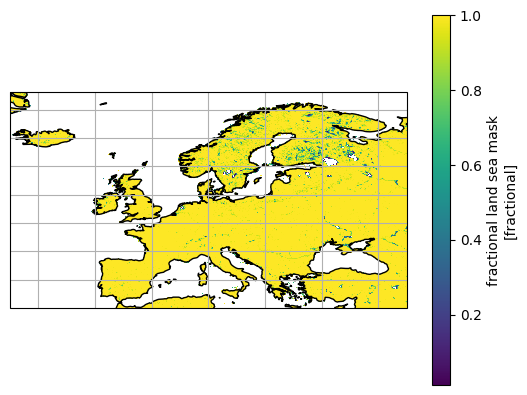

In [5]:


toplot=slf

fig, ax = plt.subplots(subplot_kw=dict(projection=ccrs.PlateCarree()))

toplot.plot.pcolormesh(ax=ax)
ax.coastlines()
ax.gridlines()

In [44]:


DATA_PATH= "/home/pietaril/Documents/data/JSBACH_CO2/JSBACH_202503/version_without_slf_coefficient/half_processed/res_0.125_combined_by_year"
PATH_SLF = "/home/pietaril/Documents/data/JSBACH_CO2/JSBACH_202503/jsbach_slf_correction.nc"
OUT_PATH= "/home/pietaril/Documents/data/JSBACH_CO2/JSBACH_202503/slf_corrected/corrected_rawdata/"
ds_coeff = xr.open_dataset(PATH_SLF)
slf = ds_coeff.slf

ds_coeff.close()
fnames = [os.path.join(DATA_PATH, f) for f in os.listdir(DATA_PATH)]
fnames.sort()
for f in fnames[12:]:
    ds = xr.open_dataset(f)
    #ds.close()
    #expand time dimension to match the data
    flux = ds.flux_bio.copy(deep=True)
    ds.close()
    slf_expanded = slf.expand_dims(time=flux.time)

    flux = flux*slf_expanded.values
   
    flux.attrs.update({"description": "JSBACH 202503 CO2 net flux to atmosphere with corrected grid, multiplied by lsf (fractional land-sea mask).",
                        "units": "mol(CO2) m-2(grid box) s-1"})
    year = flux.time.dt.year.values[0]
    outname = f"CO2_bio_regional_{str(year)}.nc"
    flux.to_netcdf(os.path.join(OUT_PATH, outname))#, encoding={'time':{'units': "days since 1900-01-01"}})
   



/home/pietaril/.local/lib/python3.10/site-packages/xarray/coding/times.py:150: SerializationWarning: Ambiguous reference date string: 1-1-1. The first value is assumed to be the year hence will be padded with zeros to remove the ambiguity (the padded reference date string is: 0001-1-1). To remove this message, remove the ambiguity by padding your reference date strings with zeros.
  warnings.warn(warning_msg, SerializationWarning)
/home/pietaril/.local/lib/python3.10/site-packages/xarray/coding/times.py:688: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  dtype = _decode_cf_datetime_dtype(data, units, calendar, self.use_cftime)
/home/pietaril/.local/lib/python3.10/site-packages/xarray/core/indexing.py:524: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  retu

: 

In [3]:
ds = xr.open_dataset("/home/pietaril/Documents/data/JSBACH_CO2/JSBACH_202503/slf_corrected/corrected_rawdata/CO2_bio_regional_2009.nc")
ds

<xarray.Dataset>
Dimensions:    (longitude: 560, latitude: 304, time: 8760)
Coordinates:
  * longitude  (longitude) float32 -24.94 -24.81 -24.69 ... 44.69 44.81 44.94
  * latitude   (latitude) float32 35.06 35.19 35.31 35.44 ... 72.69 72.81 72.94
  * time       (time) datetime64[ns] 2009-01-01T00:39:59.999999488 ... 2009-1...
Data variables:
    flux_bio   (time, latitude, longitude) float64 ...

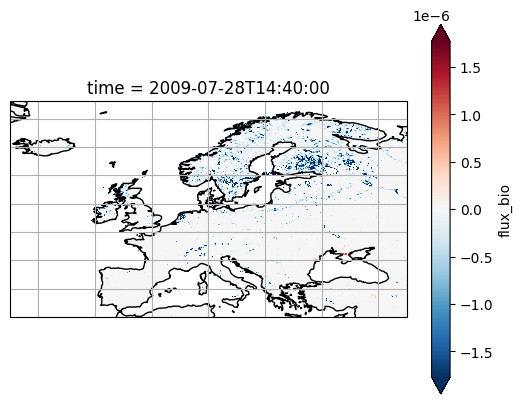

In [ ]:
DATA_PATH= "/home/pietaril/Documents/data/JSBACH_CO2/JSBACH_202503/version_without_slf_coefficient/half_processed/res_0.125_combined_by_year"
OUT_PATH= "/home/pietaril/Documents/data/JSBACH_CO2/JSBACH_202503/slf_corrected/corrected_rawdata/"

#compare corrected maps to the originals
fnames_orig = [os.path.join(DATA_PATH, f) for f in os.listdir(DATA_PATH)]
fnames_orig.sort()
fnames_cor = [os.path.join(OUT_PATH, f) for f in os.listdir(OUT_PATH)]
fnames_cor.sort()

ind = 0
#aoi = [21, 22, 60.5, 61.5]

dsorig = xr.open_dataset(fnames_orig[ind])
dscor = xr.open_dataset(fnames_cor[ind])
timeind = 5006
fluxorig = dsorig.flux_bio[timeind,:,:]
fluxcor = dscor.flux_bio[timeind, :, :]
dsorig.close()
dscor.close()
cmap = mpl.colormaps["seismic"]
diff = fluxorig-fluxcor
#subset = select_area(aoi, diff)

fig, ax = plt.subplots(1,3,  subplot_kw=dict(projection=ccrs.PlateCarree()))


diff.plot.pcolormesh(ax=ax, robust=True)
ax.coastlines()
ax.gridlines()



In [38]:
ds = xr.open_dataset(fnames_cor[0])
ds

<xarray.Dataset>
Dimensions:    (longitude: 560, latitude: 304, time: 8760)
Coordinates:
  * longitude  (longitude) float32 -24.94 -24.81 -24.69 ... 44.69 44.81 44.94
  * latitude   (latitude) float32 35.06 35.19 35.31 35.44 ... 72.69 72.81 72.94
  * time       (time) datetime64[ns] 2009-01-01T00:39:59.999999488 ... 2009-1...
Data variables:
    flux_bio   (time, latitude, longitude) float64 ...

## Middle step 2: Extend land fluxes a couple of pixels into the ocean before regridding
* Done on a separate .py-script in LUMI

In [3]:
#examine the padded data
PADDED_PATH = "/home/pietaril/Documents/data/JSBACH_CO2/JSBACH_202503/half_processed/padded/CO2_JSBACH_202503_padded_2018.nc"
ds = xr.open_dataset(PADDED_PATH)
ds

<xarray.Dataset>
Dimensions:    (longitude: 560, latitude: 304, time: 8760)
Coordinates:
  * longitude  (longitude) float32 -24.94 -24.81 -24.69 ... 44.69 44.81 44.94
  * latitude   (latitude) float32 35.06 35.19 35.31 35.44 ... 72.69 72.81 72.94
  * time       (time) datetime64[ns] 2018-12-31T23:40:00 ... 2018-12-31T22:40:00
Data variables:
    flux_bio   (time, latitude, longitude) float32 ...
Attributes:
    description:  Biospheric CO2 net fluxes to atmosphere from JSBACH 202503,...
    units:        mol m-2 s-1

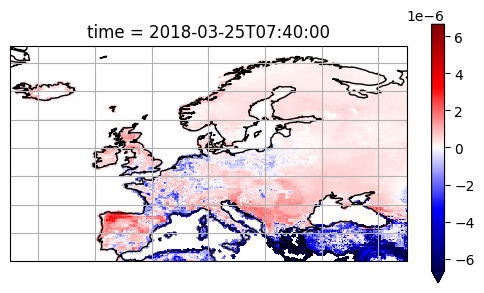

In [4]:

toplot= ds.flux_bio[2000,:, :]

cbar_label = ""#"emission [$g(CO_2)$ $m^{-2}$ $yr^{-1}$]"
variable = "flux_bio"
cbar_shrink = 0.7
cmap = mpl.colormaps["seismic"]
#suptitle="Average yearly CO$_2$ fire emissions $2018-2022$"




fig, ax = plt.subplots(subplot_kw=dict(projection=ccrs.PlateCarree()))

toplot.plot.pcolormesh(ax=ax, 
                                      robust=True, cmap=cmap,
                                       cbar_kwargs=dict(label=cbar_label, shrink=cbar_shrink))
ax.coastlines()
ax.gridlines()

## Step 3: Regrid to 0.1 deg resolution
* Memory-intensive: done in LUMI

### Examine the final product

In [6]:
DATA_PATH ="/home/pietaril/Documents/data/JSBACH_CO2/JSBACH_202503/slf_corrected/CO2_prior_flux_JSBACH_202503_res_0.1_2023.nc"
ds = xr.open_dataset(DATA_PATH)
ds

    

<xarray.Dataset>
Dimensions:    (time: 8760, latitude: 380, longitude: 700)
Coordinates:
  * time       (time) datetime64[ns] 2023-01-01T00:39:59.999999488 ... 2023-1...
  * longitude  (longitude) float64 -24.95 -24.85 -24.75 ... 44.75 44.85 44.95
  * latitude   (latitude) float64 35.05 35.15 35.25 35.35 ... 72.75 72.85 72.95
Data variables:
    flux_bio   (time, latitude, longitude) float64 ...
Attributes:
    description:  Biospheric CO2 net fluxes to atmosphere from JSBACH 202503,...
    units:        kg(CO2) m-2 hr-1

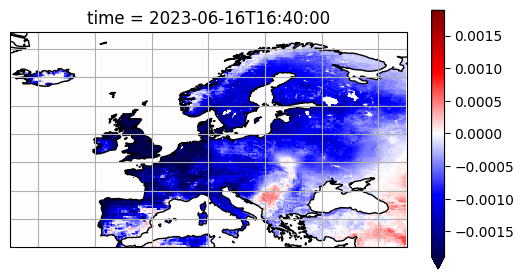

In [8]:
import matplotlib.pyplot as plt


toplot= ds.flux_bio[4000,:, :]

cbar_label = ""#"emission [$g(CO_2)$ $m^{-2}$ $yr^{-1}$]"
variable = "flux_bio"
cbar_shrink = 0.7
cmap = mpl.colormaps["seismic"]
#suptitle="Average yearly CO$_2$ fire emissions $2018-2022$"




fig, ax = plt.subplots(subplot_kw=dict(projection=ccrs.PlateCarree()))

toplot.plot.pcolormesh(ax=ax, 
                                      robust=True, cmap=cmap,
                                       cbar_kwargs=dict(label=cbar_label, shrink=cbar_shrink))
ax.coastlines()
ax.gridlines()


# Convert to g/m2/yr for Tuula's plots
* Done on a separate script in LUMI

In [1]:
YEARLYPATH = "/home/pietaril/Documents/data/JSBACH_CO2/JSBACH_202503/slf_corrected/g_m-2_yr-1/yearly_NEE_2010.nc"
ds = xr.open_dataset(YEARLYPATH)

data = ds["flux_bio"][0,:,:]
year = ds.time.dt.year.values[0]


NameError: name 'xr' is not defined

In [88]:
ds

<xarray.Dataset>
Dimensions:    (longitude: 700, latitude: 380, time: 1)
Coordinates:
  * longitude  (longitude) float64 -24.95 -24.85 -24.75 ... 44.75 44.85 44.95
  * latitude   (latitude) float64 35.05 35.15 35.25 35.35 ... 72.75 72.85 72.95
  * time       (time) datetime64[ns] 2015-01-01T00:39:59.999999488
Data variables:
    flux_bio   (time, latitude, longitude) float64 ...
Attributes:
    description:  Gridded yearly biospheric CO2 fluxes computed from hourly N...
    units:        g m-2 yr-1

In [67]:
data.values.max()

1225.3391927391106

In [68]:
data.values.min()

-1633.1300167116417

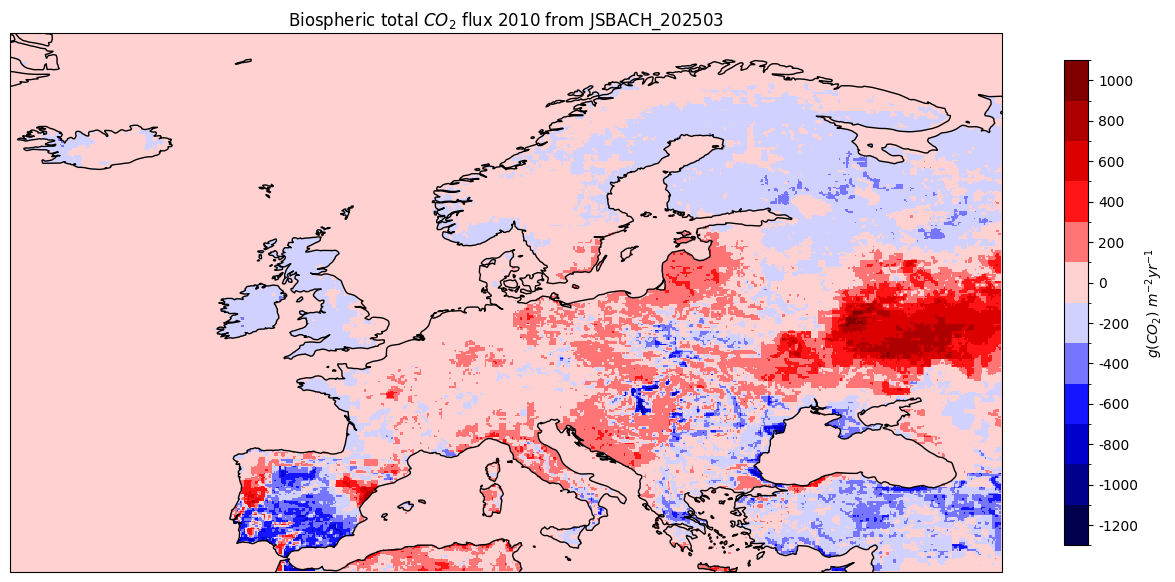

In [139]:



# Define the boundaries for the segments
boundaries = np.arange(-1300, 1300,200)
midpoints = (boundaries[:-1] + boundaries[1:]) / 2  # Calculate midpoints of each segment
cmap = mpl.colormaps["seismic"]

fig, ax = plt.subplots(figsize = (16,9),subplot_kw=dict(projection=ccrs.PlateCarree()))

# Plot the data using pcolormesh with levels
im = data.plot.pcolormesh(ax=ax, cmap=cmap, levels=boundaries, add_colorbar=False)

# Customize the colorbar
colorbar = plt.colorbar(im, ax=ax, boundaries=boundaries, ticks=midpoints, shrink=0.7)
colorbar.set_label("$g(CO_2)$ $m^{-2} yr^{-1}$")
colorbar.set_ticklabels([f'{x:.0f}' for x in midpoints])

# Add coastlines
ax.coastlines()

plt.title(f"Biospheric total $CO_2$ flux {year} from JSBACH_202503")

figname = f"JSBACH_202503_slf_corrected_CO2_year_tot_gridmap_{year}.png"
FIGPATH = "/home/pietaril/Documents/plots/JSBACH/yearly_grid_tots/"
plt.savefig(os.path.join(FIGPATH, figname))
plt.show()


## Kiiminki plots


### Compute yearly average

In [145]:
HIGHRES_PATH = "/home/pietaril/Documents/data/JSBACH_CO2/JSBACH_202503/slf_corrected/g_m-2_yr-1"
#take a slightly larger domain than the one one the plot
aoi_kii_larger = [21.0, 29.0, 63.9, 67] #[22.5, 28.5, 64, 66.5] 

fnames_yearly = [os.path.join(HIGHRES_PATH, f) for f in os.listdir(HIGHRES_PATH)]
yearly_datasets = [xr.open_dataset(f) for f in fnames_yearly]
#combine the yearly fluxgrids to a single dataset
ds_allyears = xr.concat(yearly_datasets, dim="time") 
ds_allyears = ds_allyears.sortby("time")

#ave = ds_allyears.mean(dim="time")

kii = select_area(aoi_kii_larger, ds_allyears)
ave = kii.mean(dim="time")

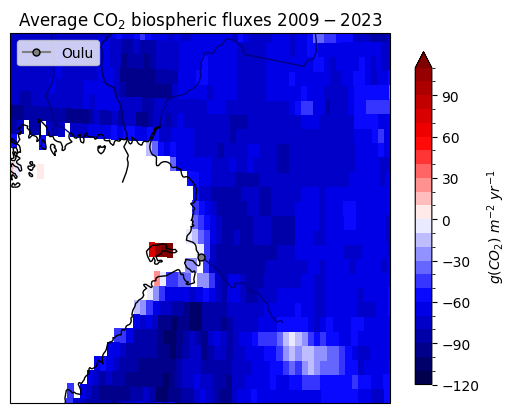

In [84]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.ticker import MultipleLocator

from matplotlib import colors


suptitle="Average CO$_2$ biospheric fluxes $2009-2023$"
cmap = mpl.colormaps["seismic"] #truncate_colormap(mpl.colormaps["seismic"], minval=0.5)
cbar_shrink = 0.9
cbar_label = "$g(CO_2)$ $m^{-2}$ $yr^{-1}$"
extent = [22.5, 28.5, 64, 66.5]
ds = ave["flux_bio"]

#divnorm=colors.TwoSlopeNorm(vmin=-110, vcenter=0., vmax=210)

# Set up the map with a Plate Carree projection
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.epsg('3067')})
ax.set_extent(extent, crs=ccrs.PlateCarree())  # Central Finland area

# Add features such as borders and coastlines
ax.add_feature(cfeature.BORDERS, linestyle='-')
ax.add_feature(cfeature.COASTLINE)

# Add rivers
ax.add_feature(cfeature.RIVERS, edgecolor='navy')

# Add a dot for Oulu
oulu_lat, oulu_lon = 65.0121, 25.4651  # Latitude and Longitude of Oulu
ax.plot(oulu_lon, oulu_lat, color='grey', markeredgecolor='black', marker='o', markersize=5, label='Oulu', transform=ccrs.PlateCarree() )

ds.where(ds!=0).plot(ax=ax, cmap=cmap, transform = ccrs.PlateCarree(), levels = np.arange(-120, 120, 10),
                                       cbar_kwargs=dict(label=cbar_label, shrink=cbar_shrink))

# Add a legend
ax.legend(loc='upper left')
ax.set_title(suptitle)
figpath = "/home/pietaril/Documents/plots/Kiiminki/"
figname = "CO2_bio_slf_corrected_Finland_Ouluregion.pdf"
plt.savefig(os.path.join(figpath, figname))
# Show the plot
plt.show()

## Compare to original coarse resolution

In [4]:
# Compute yearly fluxes with the original resolution data for comparison

def hourly_kgm2hr_to_gm2yr(ds, variable):
    """Unit conversion for hourly time resolution data from unit kg/m2/hr to g/m2/yr"""

    #hourly to yearly
    out = ds[variable].sum(dim="time")
    #kg to g
    out = out*1000
    #pick the first timestamp as the time axis value to represent the year
    time = ds["time"].values[0]
    out = out.to_dataset()
    out.coords["time"] = (time) 
    out = out.expand_dims("time")
    return out

COARSEPATH = "/home/pietaril/Documents/data/JSBACH_CO2/JSBACH_202503/half_processed/res_0.125_combined_by_year"
fnames = [os.path.join(COARSEPATH, f) for f in os.listdir(COARSEPATH)]
variable = "flux_bio"
aoi_kii_larger = [21.0, 29.0, 63.9, 67]
ls = []

#compute and save to file g/m2/yr grids
for fname in fnames:
    year = fname[-7:-3]
    print(f"Computing yearly {variable} fluxes for {year}")
    ds = xr.open_dataset(fname)
    subset = select_area(aoi_kii_larger, ds)
    ds.close()
    
    # unit conversion from mol(CO2) m-2(grid box) s-1 to kg m-2 hr-1
    co2molmass = 44.009
    coeff = co2molmass*3.6 # 60*60*0.001=3.6
    subset[variable] = subset[variable]*coeff
    yearly = hourly_kgm2hr_to_gm2yr(subset, variable)
    ls.append(yearly)
  

Computing yearly flux_bio fluxes for 2023
Computing yearly flux_bio fluxes for 2022
Computing yearly flux_bio fluxes for 2015
Computing yearly flux_bio fluxes for 2018
Computing yearly flux_bio fluxes for 2010
Computing yearly flux_bio fluxes for 2009
Computing yearly flux_bio fluxes for 2020
Computing yearly flux_bio fluxes for 2016
Computing yearly flux_bio fluxes for 2019
Computing yearly flux_bio fluxes for 2014
Computing yearly flux_bio fluxes for 2021
Computing yearly flux_bio fluxes for 2013
Computing yearly flux_bio fluxes for 2011
Computing yearly flux_bio fluxes for 2017
Computing yearly flux_bio fluxes for 2012


In [5]:


#combine the yearly fluxgrids to a single dataset
coarse_allyears = xr.concat(ls, dim="time") 
coarse_allyears = coarse_allyears.sortby("time")

#compute the yearly mean
coarse_ave = coarse_allyears.mean(dim="time")

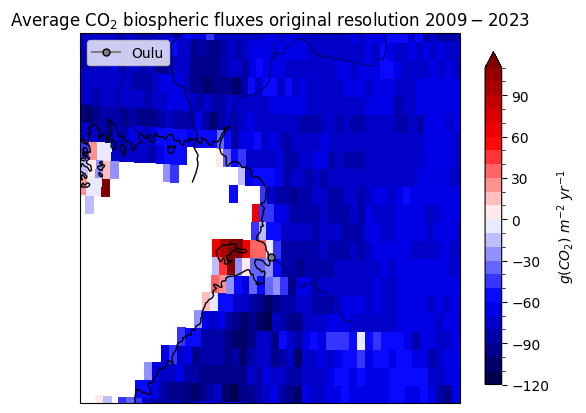

In [ ]:



suptitle="Average CO$_2$ biospheric fluxes original resolution $2009-2023$"
cmap = mpl.colormaps["seismic"] #truncate_colormap(mpl.colormaps["seismic"], minval=0.5)
cbar_shrink = 0.9
cbar_label = "$g(CO_2)$ $m^{-2}$ $yr^{-1}$"
extent = [22.5, 28.5, 64, 66.5]
ds = coarse_ave["flux_bio"]

#divnorm=colors.TwoSlopeNorm(vmin=-110, vcenter=0., vmax=210)

# Set up the map with a Plate Carree projection
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.epsg('3067')})
ax.set_extent(extent, crs=ccrs.PlateCarree())  # Central Finland area

# Add features such as borders and coastlines
ax.add_feature(cfeature.BORDERS, linestyle='-')
ax.add_feature(cfeature.COASTLINE)

# Add rivers
ax.add_feature(cfeature.RIVERS, edgecolor='navy')

# Add a dot for Oulu
oulu_lat, oulu_lon = 65.0121, 25.4651  # Latitude and Longitude of Oulu
ax.plot(oulu_lon, oulu_lat, color='grey', markeredgecolor='black', marker='o', markersize=5, label='Oulu', transform=ccrs.PlateCarree() )

ds.where(ds!=0).plot(ax=ax, cmap=cmap, transform = ccrs.PlateCarree(), levels = np.arange(-120, 120, 10),
                                       cbar_kwargs=dict(label=cbar_label, shrink=cbar_shrink))

# Add a legend
ax.legend(loc='upper left')
ax.set_title(suptitle)
figpath = "/home/pietaril/Documents/plots/Kiiminki/"
figname = "CO2_bio_Finland_Ouluregion_0.125.pdf"
plt.savefig(os.path.join(figpath, figname))
# Show the plot
plt.show()

In [8]:
coarse_ave.max()

<xarray.Dataset>
Dimensions:   ()
Data variables:
    flux_bio  float64 246.3

### Monthly Kiiminki

In [14]:
monthly_means = xr.open_dataset("/home/pietaril/Documents/data/JSBACH_CO2/JSBACH_202503/slf_corrected/kiiminki_jsbach_monthly_slf_corrected.nc")
monthly_means

<xarray.Dataset>
Dimensions:    (longitude: 80, latitude: 31, month: 12)
Coordinates:
  * longitude  (longitude) float64 21.05 21.15 21.25 21.35 ... 28.75 28.85 28.95
  * latitude   (latitude) float64 63.95 64.05 64.15 64.25 ... 66.75 66.85 66.95
  * month      (month) int64 1 2 3 4 5 6 7 8 9 10 11 12
Data variables:
    flux_bio   (month, latitude, longitude) float64 ...

In [15]:
monthly_means.min()

<xarray.Dataset>
Dimensions:   ()
Data variables:
    flux_bio  float64 -0.0005615

In [67]:
6*1e-4

0.0006000000000000001

In [63]:
monthly_means.max()

<xarray.Dataset>
Dimensions:   ()
Data variables:
    flux_bio  float64 0.0002974

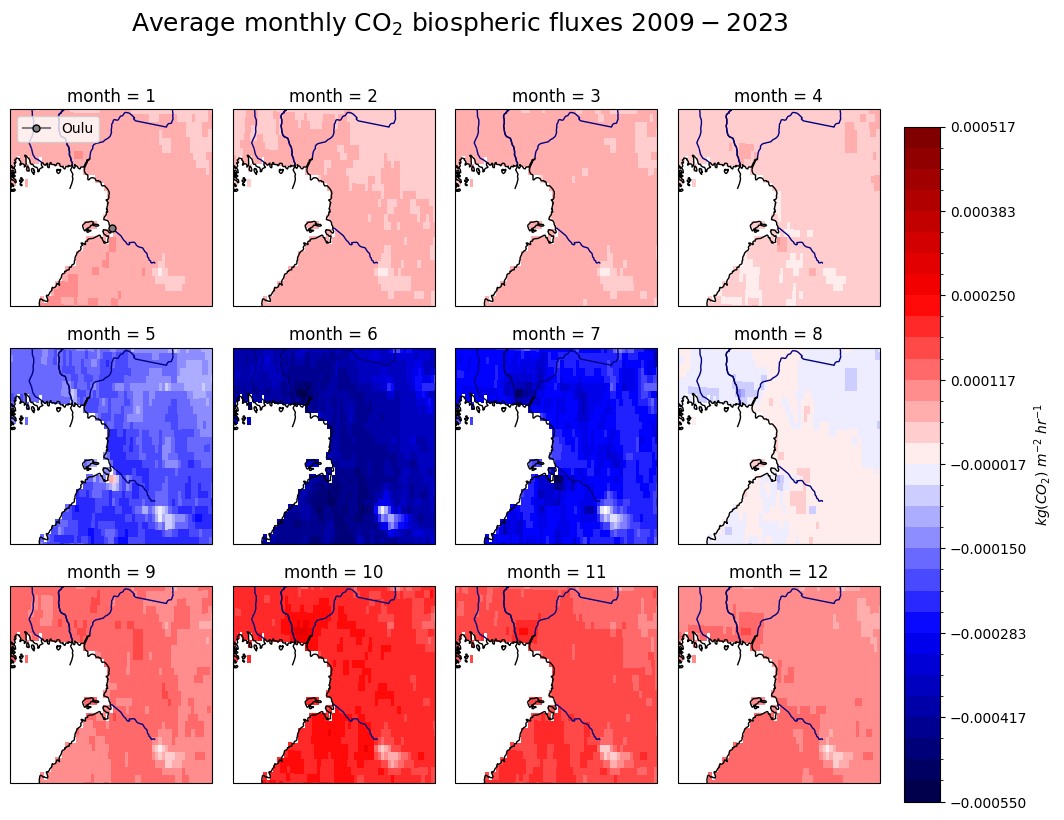

In [17]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.ticker import MultipleLocator


suptitle="Average monthly CO$_2$ biospheric fluxes $2009-2023$"
cmap = mpl.colormaps["seismic"] #truncate_colormap(mpl.colormaps["seismic"], minval=0.5)
cbar_shrink = 0.9
cbar_label = "$kg(CO_2)$ $m^{-2}$ $hr^{-1}$"
extent = [22.5, 28.5, 64, 66.5]
ds = monthly_means["flux_bio"]

# Set up the map with a Plate Carree projection
fig, axs = plt.subplots(3, 4, figsize= (12,9), subplot_kw={'projection': ccrs.epsg('3067')})
i = 1
for ax in axs.flatten():
    ax.set_extent(extent, crs=ccrs.PlateCarree())  # Central Finland area

    # Add features such as borders and coastlines
    ax.add_feature(cfeature.BORDERS, linestyle='-')
    ax.add_feature(cfeature.COASTLINE)

    # Add rivers
    ax.add_feature(cfeature.RIVERS, edgecolor='navy')

    # Add a dot for Oulu
    if i == 1:
        oulu_lat, oulu_lon = 65.0121, 25.4651  # Latitude and Longitude of Oulu
        ax.plot(oulu_lon, oulu_lat, color='grey', markeredgecolor='black', marker='o', markersize=5, label='Oulu', transform=ccrs.PlateCarree() )
        # Add a legend
        ax.legend(loc='upper left')

    mon = ds.sel(month=i)

    im = mon.where(mon!=0).plot(ax=ax, cmap=cmap, transform = ccrs.PlateCarree(), levels=np.arange(-5.5*1e-4, 5.5*1e-4, 1e-4/3),
                                        add_colorbar=False)
    
    
    i += 1
# Adjust layout to make space for the colorbar
fig.subplots_adjust(right=0.85, wspace=0.1, hspace=0.1)

# Add a single colorbar for all plots

cbar_ax = fig.add_axes([0.87, 0.1, 0.03, 0.75])
#fig.colorbar(im, cax=cbar_ax)
fig.colorbar(im, label=cbar_label, cax=cbar_ax, shrink=0.6)
    
fig.suptitle(suptitle, fontsize=18)
figpath = "/home/pietaril/Documents/plots/Kiiminki/"
figname = "CO2_bio_slf_corrected_monthly_Finland_Ouluregion.pdf"
plt.savefig(os.path.join(figpath, figname))
# Show the plot
plt.show()

## Difference between slf corrected and the old ones without correction

In [148]:
#difference between corrected and non-corrected
OLD_PATH = "/home/pietaril/Documents/data/JSBACH_CO2/JSBACH_202503/version_without_slf_coefficient/processed/g_m-2_yr-1/"

fnames_old = [os.path.join(OLD_PATH, f) for f in os.listdir(OLD_PATH)]
yearly_old = [xr.open_dataset(f) for f in fnames_old]
#combine the yearly fluxgrids to a single dataset
ds_old = xr.concat(yearly_old, dim="time") 
ds_old = ds_old.sortby("time")
kii_old = select_area(aoi_kii_larger, ds_old)
ave_old = kii_old.mean(dim="time")

diff = ave["flux_bio"]-ave_old["flux_bio"]
diff.values.min()

-21.889415981746765

In [149]:
diff.values.max()

38.83647819827924

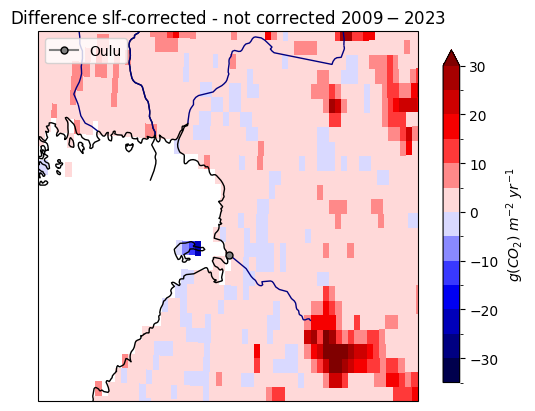

In [152]:



suptitle="Difference slf-corrected - not corrected $2009-2023$"
cmap = mpl.colormaps["seismic"] #truncate_colormap(mpl.colormaps["seismic"], minval=0.5)
cbar_shrink = 0.9
cbar_label = "$g(CO_2)$ $m^{-2}$ $yr^{-1}$"
extent = [22.5, 28.5, 64, 66.5]
ds = diff

#divnorm=colors.TwoSlopeNorm(vmin=-110, vcenter=0., vmax=210)

# Set up the map with a Plate Carree projection
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.epsg('3067')})
ax.set_extent(extent, crs=ccrs.PlateCarree())  # Central Finland area

# Add features such as borders and coastlines
ax.add_feature(cfeature.BORDERS, linestyle='-')
ax.add_feature(cfeature.COASTLINE)

# Add rivers
ax.add_feature(cfeature.RIVERS, edgecolor='navy')

# Add a dot for Oulu
oulu_lat, oulu_lon = 65.0121, 25.4651  # Latitude and Longitude of Oulu
ax.plot(oulu_lon, oulu_lat, color='grey', markeredgecolor='black', marker='o', markersize=5, label='Oulu', transform=ccrs.PlateCarree() )

ds.where(ds!=0).plot(ax=ax, cmap=cmap, transform = ccrs.PlateCarree(), levels = np.arange(-35, 35, 5),
                                       cbar_kwargs=dict(label=cbar_label, shrink=cbar_shrink))

# Add a legend
ax.legend(loc='upper left')
ax.set_title(suptitle)
figpath = "/home/pietaril/Documents/plots/Kiiminki/"
figname = "CO2_correction_difference_Finland_Ouluregion.pdf"
plt.savefig(os.path.join(figpath, figname))
# Show the plot
plt.show()


# Compute domain totals for Finland

In [144]:
from areagrid import areagrid

def g_per_m2_per_yr_to_Mt_per_yr(ds, var):
    
    lat = ds["latitude"].values
    lon = ds["longitude"].values


    # compute the areas of the gridcells in the data
    grid_of_areas = areagrid(lat, lon)

    # pointwise multiplication by area
    totals = ds[var] * grid_of_areas


    domain_tot = totals.sum(dim=("latitude", "longitude"))

    #g to Mt
    domain_tot = domain_tot*1e-12

    return domain_tot


def get_fin_mask(data_to_be_masked):

    """Helper function to get Finland mask with the same dimensionality
    as the data to be masked (when the data has the aoi used in this function. Could
    later improve this to read the aoi also from the input data)"""

    MASK_PATH = "/home/pietaril/Documents/data/masks/country_masks/eez_01x01.nc4"
    ds_mask = xr.open_dataset(MASK_PATH)
    msk = ds_mask.Band1
    ds_mask.close()

    #limit the mask first to the same domain where the saved g/m2/yr values are
    latmin = data_to_be_masked["latitude"].values.min()-0.05
    latmax = data_to_be_masked["latitude"].values.max()+0.05
    lonmin = data_to_be_masked["longitude"].values.min()-0.05
    lonmax = data_to_be_masked["longitude"].values.max()+0.05
    aoi = [lonmin, lonmax, latmin, latmax]
    msk = select_area(aoi,msk)

    #Finland = 83
    msk_fin = msk==83

    #rename dimensions to match the ones in the data
    rename_map = {
        "lat": "latitude",
        "lon": "longitude",
        }
    msk_fin = msk_fin.rename(rename_map)

    #expand time dimension to match the data
    msk_fin_expanded = msk_fin.expand_dims(time=data_to_be_masked.time)

    return msk_fin_expanded

In [ ]:
fnames_yearly = [os.path.join(YEARLY_PATH, f) for f in os.listdir(YEARLY_PATH)]
yearly_datasets = [xr.open_dataset(f) for f in fnames_yearly]
#combine the yearly fluxgrids to a single dataset
ds_allyears = xr.concat(yearly_datasets, dim="time") 
ds_allyears = ds_allyears.sortby("time")

#expand the mask to match the dimensions of the data
msk_fin_expanded = get_fin_mask(ds_allyears)
fin_gm2yr = ds_allyears.where(msk_fin_expanded.values, drop=False)
fin_tot = g_per_m2_per_yr_to_Mt_per_yr(fin_gm2yr)

# Plot

In [24]:
fnames_yearly = [os.path.join(YEARLY_PATH, f) for f in os.listdir(YEARLY_PATH)]
yearly_datasets = [xr.open_dataset(f) for f in fnames_yearly]
#combine the yearly fluxgrids to a single dataset
ds_allyears = xr.concat(yearly_datasets, dim="time") 
ds_allyears = ds_allyears.sortby("time")

In [69]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import cartopy.crs as ccrs

def plot_yearly_fluxes(ds, variable, ncols, cmap, cbar_label, suptitle=None):
    # Sample data from your dataset (replace 'ds_allyears' and 'emi_fire' with your data variables)
    data = ds[variable]

    # Define colorbar shrink parameter
    cbar_shrink = 0.7

    # Create the plot
    g = data.plot.pcolormesh(
        x="longitude",
        y="latitude",
        col="time",
        col_wrap=ncols,
        robust=True,
        aspect=1.25,
        cmap=cmap,
        subplot_kws=dict(projection=ccrs.PlateCarree()),
        cbar_kwargs=dict(label=cbar_label, shrink=cbar_shrink),
    )

    # Calculate the total number of subplots (including blanks)
    nplots = len(data.time)  # Total number of time slices
    nrows = (nplots + ncols - 1) // ncols  # Calculate number of rows (rounding up)

    # Adjust axes to handle blank spaces correctly
    for i, ax in enumerate(g.axes.flat):
        if i < nplots:  # Plot only for valid time slices
            time = str(data.time.values[i])[0:4]
            ax.set_title(time)
            ax.coastlines()
        else:  # Completely remove unused subplots
            g.fig.delaxes(ax)

    # Adjust the suptitle to account for the colorbar space
    # Compute the amount to shift the title leftward
    colorbar_offset = (1 - cbar_shrink) / 2  # Fraction of the figure width
    title_x_adjustment = colorbar_offset * g.fig.get_figwidth()

    # Add the suptitle and position it
    if not suptitle==None:
        g.fig.suptitle(
            suptitle,
            fontsize=18,
            x=0.5 - title_x_adjustment / g.fig.get_figwidth(),  # Centered and adjusted left
            y=0.9,  
        )

    # Adjust the spacing
    g.fig.subplots_adjust(top=0.85, right=0.8, wspace=0.1, hspace=0.1)

    # Draw the plot
    plt.draw()

## Slf corrected

In [76]:
YEARLY_PATH = "/home/pietaril/Documents/data/JSBACH_CO2/JSBACH_202503/slf_corrected/g_m-2_yr-1/"

fnames_yearly = [os.path.join(YEARLY_PATH, f) for f in os.listdir(YEARLY_PATH)]
yearly_datasets = [xr.open_dataset(f) for f in fnames_yearly]
#combine the yearly fluxgrids to a single dataset
ds_allyears = xr.concat(yearly_datasets, dim="time") 
ds_allyears = ds_allyears.sortby("time")

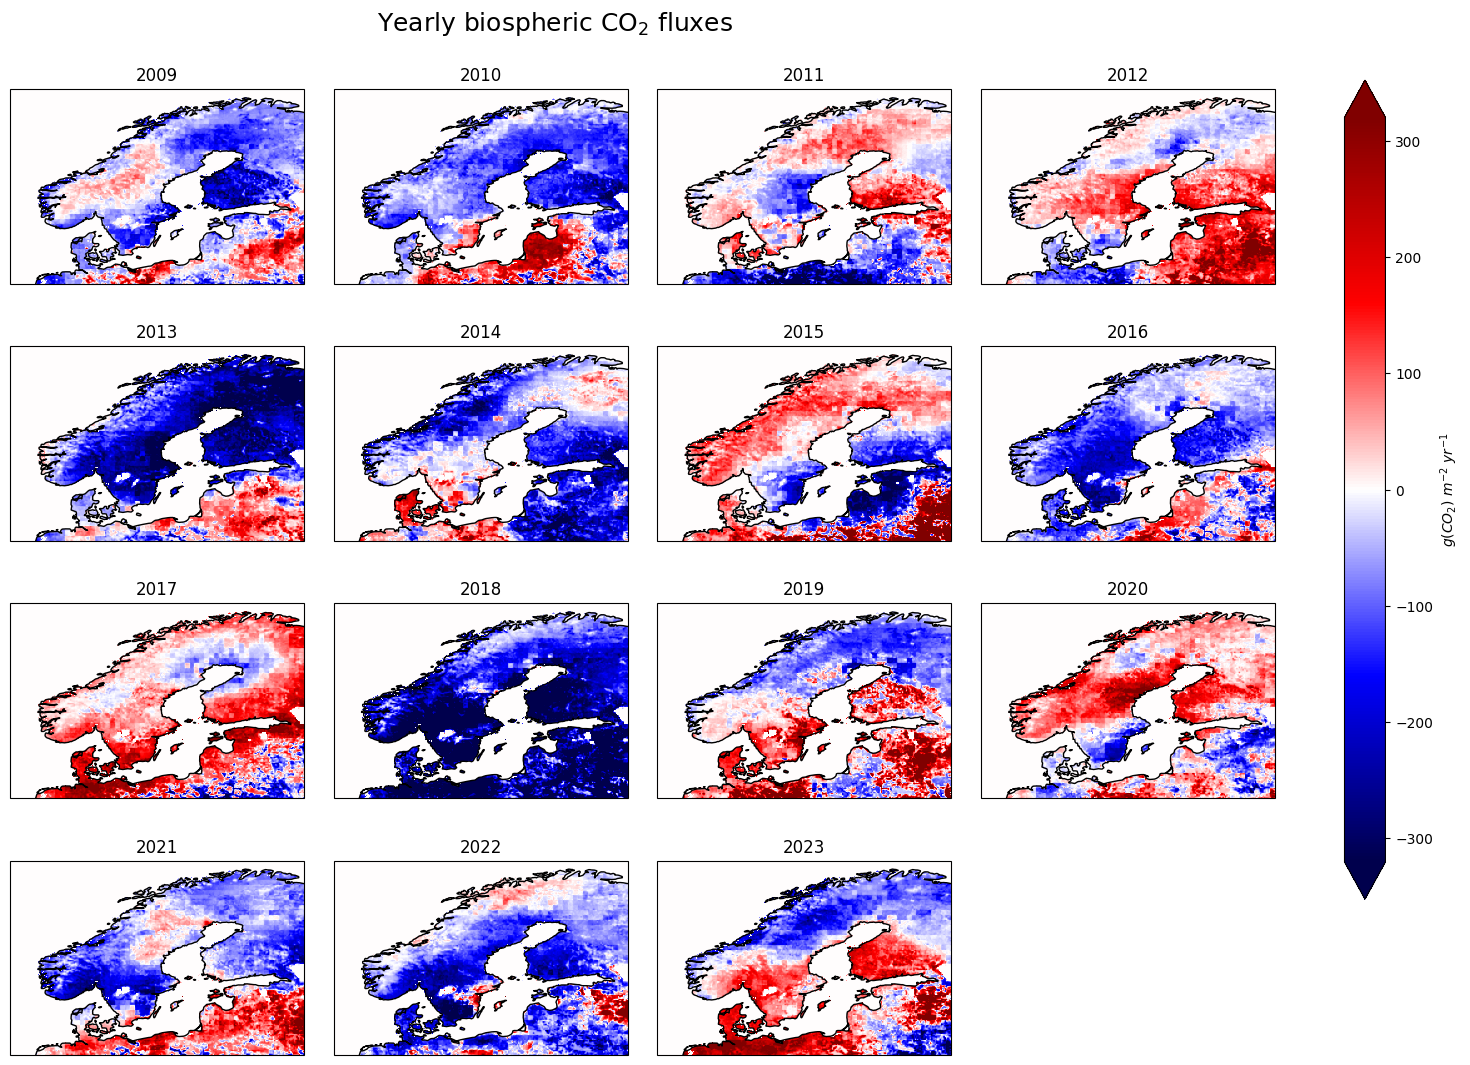

In [77]:
#With slf correction
cbar_label = "$g(CO_2)$ $m^{-2}$ $yr^{-1}$"
variable = "flux_bio"
ncols = 4
cmap =mpl.colormaps["seismic"]
suptitle="Yearly biospheric CO$_2$ fluxes"

aoi_scand = [2, 31.5, 52.5, 72]

scand = select_area(aoi_scand, ds_allyears)

plot_yearly_fluxes(scand, variable, ncols, cmap, cbar_label, suptitle)
figpath = "/home/pietaril/Documents/plots/JSBACH/"
figname = "scand_yearly_bio_CO2_fluxes.png"
#plt.savefig(figpath+figname)
plt.draw()

## Not slf-corrected

In [78]:
OLD_PATH = "/home/pietaril/Documents/data/JSBACH_CO2/JSBACH_202503/version_without_slf_coefficient/processed/g_m-2_yr-1/"

fnames_yearly = [os.path.join(OLD_PATH, f) for f in os.listdir(OLD_PATH)]
yearly_datasets = [xr.open_dataset(f) for f in fnames_yearly]
#combine the yearly fluxgrids to a single dataset
ds_without_slf = xr.concat(yearly_datasets, dim="time") 
ds_without_slf = ds_without_slf.sortby("time")

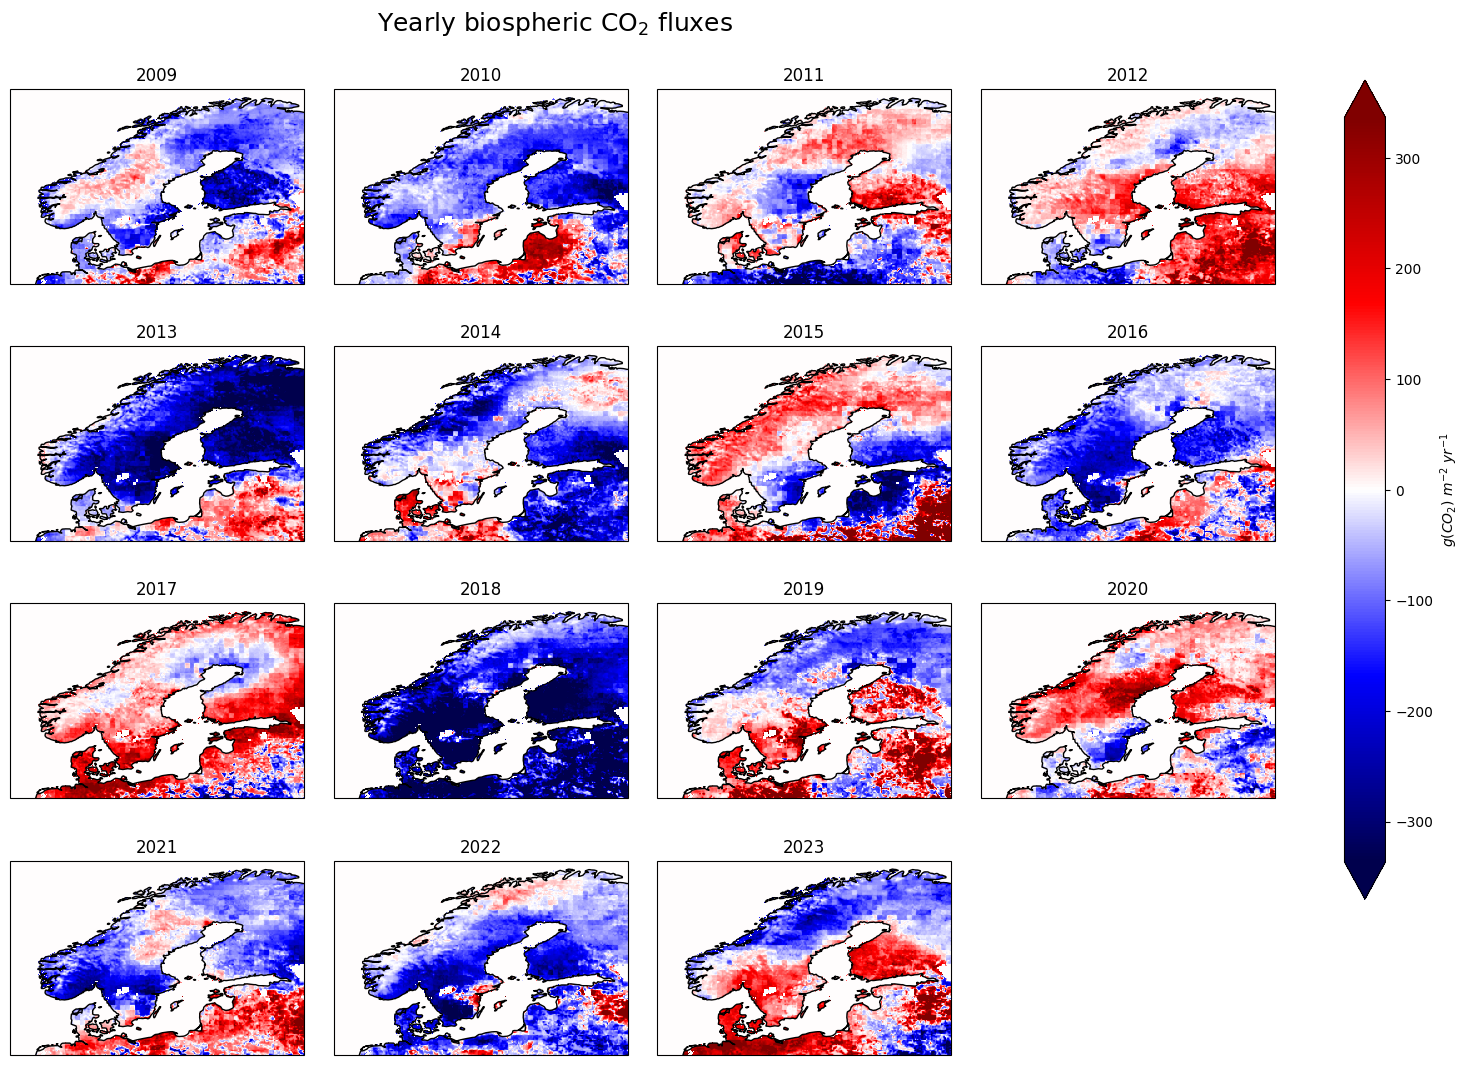

In [79]:
#Without slf correction
cbar_label = "$g(CO_2)$ $m^{-2}$ $yr^{-1}$"
variable = "flux_bio"
ncols = 4
cmap =mpl.colormaps["seismic"]
suptitle="Yearly biospheric CO$_2$ fluxes"

aoi_scand = [2, 31.5, 52.5, 72]

scand_without_slf = select_area(aoi_scand, ds_without_slf)

plot_yearly_fluxes(scand_without_slf, variable, ncols, cmap, cbar_label, suptitle)
figpath = "/home/pietaril/Documents/plots/JSBACH/"
figname = "scand_yearly_bio_CO2_fluxes_without_slf_correction.png"
#plt.savefig(figpath+figname)
plt.draw()

In [30]:
#compute the mean for the chosen range of years
years = range(2017, 2022)

scand_17_21 = scand.isel(time=scand.time.dt.year.isin(years))
scand_ave = scand_17_21.mean(dim="time")
scand_ave

<xarray.Dataset>
Dimensions:    (latitude: 195, longitude: 295)
Coordinates:
  * latitude   (latitude) float32 52.55 52.65 52.75 52.85 ... 71.75 71.85 71.95
  * longitude  (longitude) float32 2.05 2.15 2.25 2.35 ... 31.25 31.35 31.45
Data variables:
    emi_bio    (latitude, longitude) float64 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0

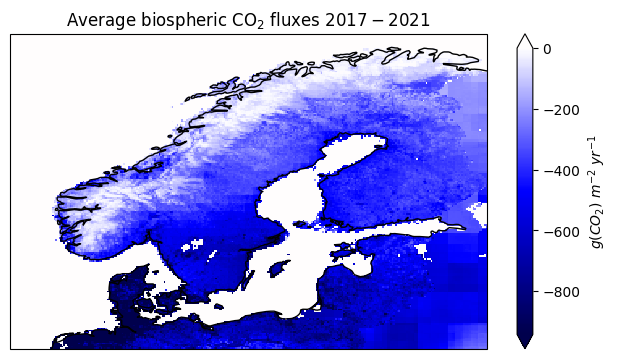

In [37]:
from truncate_colormap import truncate_colormap

cbar_label = "$g(CO_2)$ $m^{-2}$ $yr^{-1}$"
variable = "emi_bio"
cbar_shrink = 0.7
cmap = truncate_colormap(mpl.colormaps["seismic"], maxval=0.5)
suptitle="Average biospheric CO$_2$ fluxes $2017-2021$"




fig, ax = plt.subplots(subplot_kw=dict(projection=ccrs.PlateCarree()))

scand_ave["emi_bio"].plot.pcolormesh(ax=ax, 
                                      robust=True, cmap=cmap,
                                       cbar_kwargs=dict(label=cbar_label, shrink=cbar_shrink))
ax.coastlines()
ax.set_title(suptitle)
plt.tight_layout()
plt.draw()
figpath = "/home/pietaril/Documents/plots/JSBACH/"
figname = f"JSBACH_scandinavia_mean_CO2_flux_2017_2021.png"
plt.savefig(figpath+figname)
plt.draw()

# JSBACH global

* need to multiply by lsf from the jsbach.nc that corresponds to the global run
* interpolate to 2 x 2 x monthly
* unit from mol(CO2) m-2(grid box) s-1 to kg(CO2) m-2 hr-1

In [ ]:

ds = xr.open_dataset("/home/pietaril/Documents/data/JSBACH_CO2/JSBACH_global_202506/rawdata/Global_2009-01-01_jsbach.nc", chunks = {"latitude":100, "longitude":100})
ds

<xarray.Dataset>
Dimensions:       (time: 8760, lon: 720, lat: 360)
Coordinates:
  * time          (time) datetime64[ns] 2009-01-01T00:40:00 ... 2009-12-31T23...
  * lon           (lon) float64 -179.8 -179.2 -178.8 ... 178.8 179.2 179.8
  * lat           (lat) float64 -89.75 -89.25 -88.75 ... 88.75 89.25 89.75
Data variables:
    CO2_flux_net  (time, lat, lon) float32 ...
Attributes:
    CDI:          Climate Data Interface version 2.0.5 (https://mpimet.mpg.de...
    Conventions:  CF-1.6
    institution:  Max Planck Institute for Meteorology
    history:      Mon Jun 09 11:11:31 2025: cdo -f nc4c -z zip_1 -r -setgrid,...
    CDO:          Climate Data Operators version 2.0.5 (https://mpimet.mpg.de...

In [5]:
slf = xr.open_dataset("/home/pietaril/Documents/data/JSBACH_CO2/JSBACH_global_202506/jsbach_global.nc")
slf

<xarray.Dataset>
Dimensions:               (time: 12, lon: 720, lat: 360, soillev: 11, ntiles: 16)
Coordinates:
  * time                  (time) object 0001-01-31 00:00:00 ... 0001-12-31 00...
  * lon                   (lon) float64 -179.8 -179.2 -178.8 ... 179.2 179.8
  * lat                   (lat) float64 -89.75 -89.25 -88.75 ... 89.25 89.75
  * soillev               (soillev) float64 0.065 0.182 0.3926 ... 28.93 52.14
  * ntiles                (ntiles) float64 1.0 2.0 3.0 4.0 ... 14.0 15.0 16.0
Data variables: (12/38)
    soil_porosity         (lat, lon) float64 ...
    soil_field_cap        (lat, lon) float64 ...
    wilting_point         (lat, lon) float64 ...
    moisture_pot          (lat, lon) float64 ...
    hyd_cond_sat          (lat, lon) float64 ...
    bclapp                (lat, lon) float64 ...
    ...                    ...
    surf_temp             (time, lat, lon) float64 ...
    veg_fract             (time, lat, lon) float64 ...
    cover_fract           (ntiles, lat, lon) float32 ...
    cover_type            (ntiles, lat, lon) float64 ...
    shortwave             (lat, lon) float32 ...
    natural_veg           (ntiles, lat, lon) float32 ...
Attributes: (12/15)
    CDI:                          Climate Data Interface version 2.4.0 (https...
    Conventions:                  CF-1.6
    title:                        initial surface data for JSBACH
    nlct:                         22
    NCO:                          netCDF Operators version 5.2.1 (Homepage = ...
    refyear_for_cover_types:      1850
    ...                           ...
    references:                   Hagemann, S. (2002): An improved land surfa...
    institution:                  Finnish Meteorological Institute
    comment:                      Created from ESA CCI, Eur Corine and Fin Co...
    history:                      Mon May 05 09:54:19 2025: cdo -f nc4c -z zi...
    history_of_appended_files:    Fri Apr 25 11:53:34 2025: Appended file jsb...
    CDO:                          Climate Data Operators version 2.4.0 (https...

In [4]:
from dask.distributed import Client
client = Client(n_workers=os.cpu_count()-2, threads_per_worker=1)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 6
Total threads: 6,Total memory: 30.76 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:41279,Workers: 6
Dashboard: http://127.0.0.1:8787/status,Total threads: 6
Started: Just now,Total memory: 30.76 GiB
Comm: tcp://127.0.0.1:35993,Total threads: 1
Dashboard: http://127.0.0.1:44441/status,Memory: 5.13 GiB
Nanny: tcp://127.0.0.1:43265,


In [20]:
client.close()

In [ ]:
from tqdm import tqdm
DATAPATH = "/home/pietaril/Documents/data/JSBACH_CO2/JSBACH_global_202506/rawdata/"
PATH_SLF = "/home/pietaril/Documents/data/JSBACH_CO2/JSBACH_global_202506/jsbach_global.nc"
OUTPATH = "/home/pietaril/Documents/data/JSBACH_CO2/JSBACH_global_202506/global_2X2_monthly"

newlon = np.arange(-179.0, 180.0, 2)
newlat = np.arange(-89.0, 90.0, 2)

fnames = [os.path.join(DATAPATH, f) for f in os.listdir(DATAPATH)]
fnames.sort()
ds_coeff = xr.open_dataset(PATH_SLF, decode_cf=False)
slf = ds_coeff.slf
varname = "nee"

ds_coeff.close()

for f in tqdm(fnames):
    print(f)
    ds = xr.open_dataset(f, chunks={'time':100})
    
    rename_map = {
        "CO2_flux_net" : varname,
        "lat": "latitude",
        "lon": "longitude",
    }

    flux = ds.rename(rename_map)
    ds.close()
    year = flux.time.dt.year.values[0]
    flux = flux[varname]
    slf_expanded = slf.expand_dims(time=flux.time)
    #multiply by slf (sea-land-fraction) correction coefficient
    #multiplying by slf automatically changes dtype to float64
    flux = flux*slf_expanded.values
    #regrid to 2X2
    flux = flux.interp({'latitude':newlat, 'longitude':newlon})

    #set ocean cells to 0

    lsm = create_lsm_like(flux)
    flux.values[:,~lsm] = 0

    #adjust time stamps to be on the hour
    flux = flux.assign_coords(time = flux.time.dt.floor("h"))
    #resample to monthly/3-hourly
    flux = flux.sortby("time")
    flux = flux.resample(time="1MS", closed="left", label="left").mean(skipna=True)

    # Create new time coordinate with 15th of each month
    # mid_month_times = pd.date_range(
    #     start=flux.time.values[0], 
    #     periods=12, 
    #     freq='MS'
    # ) + pd.Timedelta(days=14)  # shift from start of month to 15th

    # # Replace the time coordinate
    # flux['time'] = mid_month_times

    #unit conversion from mol(CO2) m-2 s-1 to kg(CO2) m-2 hr-1
    co2molmass = 44.009
    coeff = co2molmass*3.6 # 60*60*0.001=3.6
    flux *= coeff
    
    flux.attrs = {}
    flux.attrs.update({"description": "Global biospheric CO2 net fluxes to atmosphere from JSBACH 202506, interpolated to 2 x 2 deg spatial and monthly temporal resolution",
                            "units": "kg m-2 hr-1"})

    outname = f"JSBACH_202506_global_CO2_flux_2X2_monthly_{str(year)}.nc"

    flux.to_netcdf(os.path.join(OUTPATH,outname), encoding={'time':{'units': "days since 1900-01-01", 'dtype':'float64'}, varname: {'dtype': 'float64'}})#, 'zlib': True, 'shuffle':True, 'complevel': 5}})



In [7]:
ds = xr.open_dataset("/home/pietaril/Documents/data/JSBACH_CO2/JSBACH_global_202506/global_2X2_monthly/JSBACH_202506_global_CO2_flux_2X2_monthly_2023.nc")
ds

<xarray.Dataset>
Dimensions:    (latitude: 90, longitude: 180, time: 12)
Coordinates:
  * latitude   (latitude) float64 -89.0 -87.0 -85.0 -83.0 ... 85.0 87.0 89.0
  * longitude  (longitude) float64 -179.0 -177.0 -175.0 ... 175.0 177.0 179.0
  * time       (time) datetime64[ns] 2023-01-01 2023-02-01 ... 2023-12-01
Data variables:
    nee        (time, latitude, longitude) float64 ...

In [3]:

OUTPATH = "/home/pietaril/Documents/data/JSBACH_CO2/JSBACH_global_202506/global_2X2_monthly"
fnames = [os.path.join(OUTPATH, f) for f in os.listdir(OUTPATH)]

ds = xr.open_dataset(fnames[0])
ds

<xarray.Dataset>
Dimensions:    (latitude: 90, longitude: 180, time: 12)
Coordinates:
  * latitude   (latitude) float64 -89.0 -87.0 -85.0 -83.0 ... 85.0 87.0 89.0
  * longitude  (longitude) float64 -179.0 -177.0 -175.0 ... 175.0 177.0 179.0
  * time       (time) datetime64[ns] 2021-01-15 2021-02-15 ... 2021-12-15
Data variables:
    flux_bio   (time, latitude, longitude) float64 ...

In [4]:
print(fnames[0])

/home/pietaril/Documents/data/JSBACH_CO2/JSBACH_global_202506/global_2X2_monthly/JSBACH_202506_global_CO2_flux_2X2_monthly_2021.nc


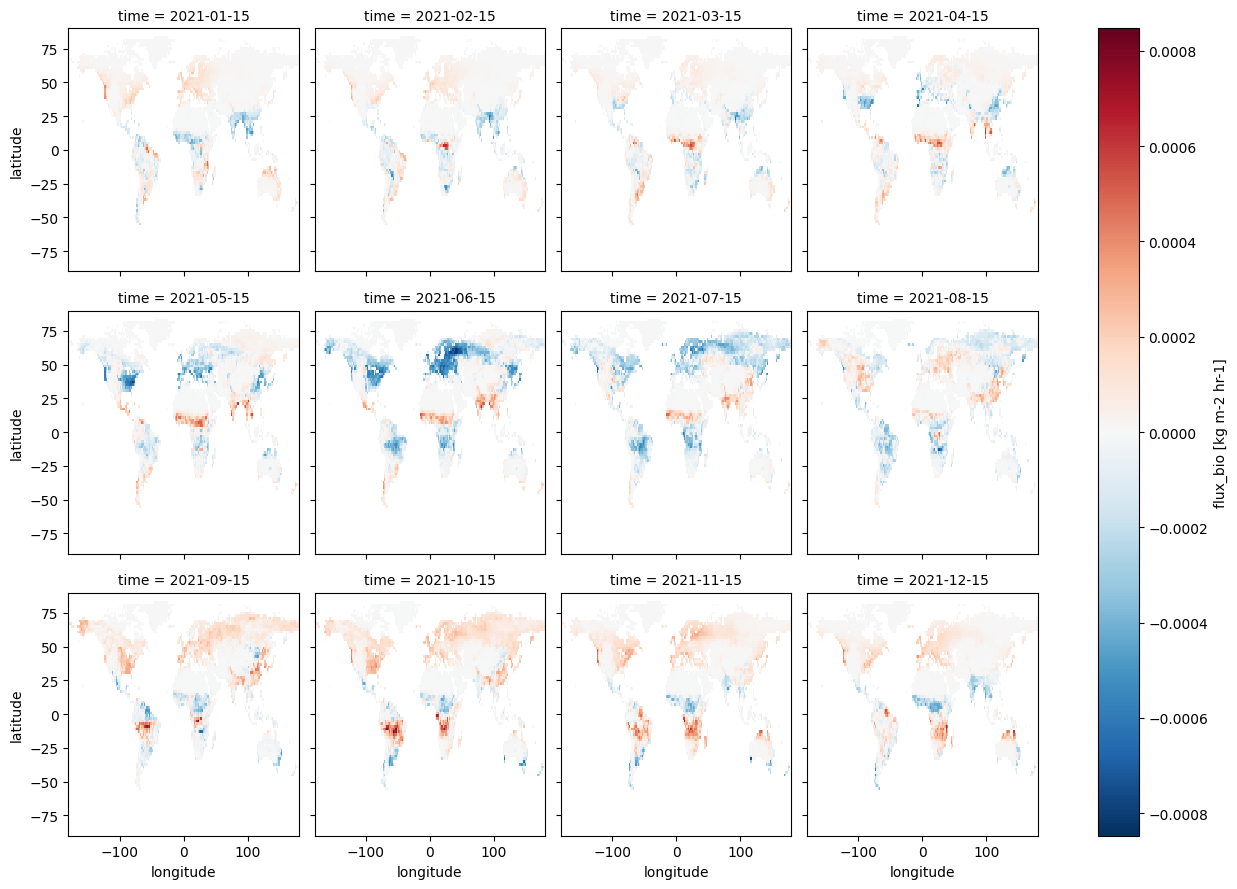

In [5]:
flux = ds.flux_bio

#fig, ax = plt.subplots(figsize = (12,9), subplot_kw={'projection':ccrs.PlateCarree()})

flux.plot(col='time', col_wrap=4)
